A/B testing is a method used to compare two versions of a strategy to determine which one performs better.
* In this case, the company ran two marketing campaigns:
  
**Control Campaign** – the original campaign strategy

**Test Campaign** – a modified campaign with potential improvements.

The goal was to analyze which campaign converts more users into customers.

## Why A/B testing?

* Make data-driven decisions
* Reduce marketing risks
* Identify which strategy performs better
* Improve customer conversion rates

Instead of guessing which campaign works better, A/B testing allows us to measure real performance using data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
control = pd.read_csv("control_group.csv")
test = pd.read_csv("test_group.csv")

In [3]:
control.head(10)

,Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase
0,Control Campaign;1.08.2019;2280;82702;56930;70...
1,Control Campaign;2.08.2019;1757;121040;102513;...
2,Control Campaign;3.08.2019;2343;131711;110862;...
3,Control Campaign;4.08.2019;1940;72878;61235;30...
4,Control Campaign;5.08.2019;1835;;;;;;;
5,Control Campaign;6.08.2019;3083;109076;87998;4...
6,Control Campaign;7.08.2019;2544;142123;127852;...
7,Control Campaign;8.08.2019;1900;90939;65217;72...
8,Control Campaign;9.08.2019;2813;121332;94896;6...
9,Control Campaign;10.08.2019;2149;117624;91257;...


In [4]:
control.columns

Index(['Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase'], dtype='object')

In [5]:
test.head()

,Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase
0,Test Campaign;1.08.2019;3008;39550;35820;3038;...
1,Test Campaign;2.08.2019;2542;100719;91236;4657...
2,Test Campaign;3.08.2019;2365;70263;45198;7885;...
3,Test Campaign;4.08.2019;2710;78451;25937;4216;...
4,Test Campaign;5.08.2019;2297;114295;95138;5863...


In [7]:
test.columns

Index(['Campaign Name;Date;Spend [USD];# of Impressions;Reach;# of Website Clicks;# of Searches;# of View Content;# of Add to Cart;# of Purchase'], dtype='object')

## Converting data to table format and changing column names 

In [8]:
test = pd.read_csv("test_group.csv", sep=';')
control = pd.read_csv("control_group.csv", sep=';')

In [9]:
control.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
test.columns = [
    "Campaign_Name",
    "Date",
    "Spend",
    "Impressions",
    "Reach",
    "Website_Clicks",
    "Searches",
    "View_Content",
    "Add_to_Cart",
    "Purchase"
]

control.columns = test.columns

In [11]:
control.columns

Index(['Campaign_Name', 'Date', 'Spend', 'Impressions', 'Reach',
       'Website_Clicks', 'Searches', 'View_Content', 'Add_to_Cart',
       'Purchase'],
      dtype='object')

In [12]:
test.columns

Index(['Campaign_Name', 'Date', 'Spend', 'Impressions', 'Reach',
       'Website_Clicks', 'Searches', 'View_Content', 'Add_to_Cart',
       'Purchase'],
      dtype='object')

In [13]:
test.head()

,Campaign_Name,Date,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


In [15]:
control.head()

,Campaign_Name,Date,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
control.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Campaign_Name   30 non-null     object 
 1   Date            30 non-null     object 
 2   Spend           30 non-null     int64  
 3   Impressions     29 non-null     float64
 4   Reach           29 non-null     float64
 5   Website_Clicks  29 non-null     float64
 6   Searches        29 non-null     float64
 7   View_Content    29 non-null     float64
 8   Add_to_Cart     29 non-null     float64
 9   Purchase        29 non-null     float64
dtypes: float64(7), int64(1), object(2)
memory usage: 2.5+ KB


In [19]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Campaign_Name   30 non-null     object
 1   Date            30 non-null     object
 2   Spend           30 non-null     int64 
 3   Impressions     30 non-null     int64 
 4   Reach           30 non-null     int64 
 5   Website_Clicks  30 non-null     int64 
 6   Searches        30 non-null     int64 
 7   View_Content    30 non-null     int64 
 8   Add_to_Cart     30 non-null     int64 
 9   Purchase        30 non-null     int64 
dtypes: int64(8), object(2)
memory usage: 2.5+ KB


In [20]:
control.describe()

,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
count,30.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000,29.000000
mean,2288.433333,109559.758621,88844.931034,5320.793103,2221.310345,1943.793103,1300.000000,522.793103
std,367.334451,21688.922908,21832.349595,1757.369003,866.089368,777.545469,407.457973,185.028642
min,1757.000000,71274.000000,42859.000000,2277.000000,1001.000000,848.000000,442.000000,222.000000
25%,1945.500000,92029.000000,74192.000000,4085.000000,1615.000000,1249.000000,930.000000,372.000000
50%,2299.500000,113430.000000,91579.000000,5224.000000,2390.000000,1984.000000,1339.000000,501.000000
75%,2532.000000,121332.000000,102479.000000,6628.000000,2711.000000,2421.000000,1641.000000,670.000000
max,3083.000000,145248.000000,127852.000000,8137.000000,4891.000000,4219.000000,1913.000000,800.000000


In [21]:
test.describe()

,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,2563.066667,74584.800000,53491.566667,6032.333333,2418.966667,1858.000000,881.533333,521.233333
std,348.687681,32121.377422,28795.775752,1708.567263,388.742312,597.654669,347.584248,211.047745
min,1968.000000,22521.000000,10598.000000,3038.000000,1854.000000,858.000000,278.000000,238.000000
25%,2324.500000,47541.250000,31516.250000,4407.000000,2043.000000,1320.000000,582.500000,298.000000
50%,2584.000000,68853.500000,44219.500000,6242.500000,2395.500000,1881.000000,974.000000,500.000000
75%,2836.250000,99500.000000,78778.750000,7604.750000,2801.250000,2412.000000,1148.500000,701.000000
max,3112.000000,133771.000000,109834.000000,8264.000000,2978.000000,2801.000000,1391.000000,890.000000


In [26]:
data = pd.concat([control, test], ignore_index=True)
data.head(10)

,Campaign_Name,Date,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase,Campaign
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,Control Campaign
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,Control Campaign
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,Control Campaign
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,Control Campaign
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Control Campaign
5,Control Campaign,6.08.2019,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,Control Campaign
6,Control Campaign,7.08.2019,2544,142123.0,127852.0,2640.0,1388.0,1106.0,1166.0,499.0,Control Campaign
7,Control Campaign,8.08.2019,1900,90939.0,65217.0,7260.0,3047.0,2746.0,930.0,462.0,Control Campaign
8,Control Campaign,9.08.2019,2813,121332.0,94896.0,6198.0,2487.0,2179.0,645.0,501.0,Control Campaign
9,Control Campaign,10.08.2019,2149,117624.0,91257.0,2277.0,2475.0,1984.0,1629.0,734.0,Control Campaign


In [27]:
data.tail(10)

,Campaign_Name,Date,Spend,Impressions,Reach,Website_Clicks,Searches,View_Content,Add_to_Cart,Purchase,Campaign
50,Test Campaign,21.08.2019,3112,133771.0,109834.0,5471.0,1995.0,1868.0,278.0,245.0,Test Campaign
51,Test Campaign,22.08.2019,2899,34752.0,27932.0,4431.0,1983.0,1131.0,367.0,276.0,Test Campaign
52,Test Campaign,23.08.2019,2407,60286.0,49329.0,5077.0,2592.0,2004.0,632.0,473.0,Test Campaign
53,Test Campaign,24.08.2019,2078,36650.0,30489.0,7156.0,2687.0,2427.0,327.0,269.0,Test Campaign
54,Test Campaign,25.08.2019,2928,120576.0,105978.0,3596.0,2937.0,2551.0,1228.0,651.0,Test Campaign
55,Test Campaign,26.08.2019,2311,80841.0,61589.0,3820.0,2037.0,1046.0,346.0,284.0,Test Campaign
56,Test Campaign,27.08.2019,2915,111469.0,92159.0,6435.0,2976.0,2552.0,992.0,771.0,Test Campaign
57,Test Campaign,28.08.2019,2247,54627.0,41267.0,8144.0,2432.0,1281.0,1009.0,721.0,Test Campaign
58,Test Campaign,29.08.2019,2805,67444.0,43219.0,7651.0,1920.0,1240.0,1168.0,677.0,Test Campaign
59,Test Campaign,30.08.2019,1977,120203.0,89380.0,4399.0,2978.0,1625.0,1034.0,572.0,Test Campaign


In [28]:
data.isnull().sum()

Campaign_Name     0
Date              0
Spend             0
Impressions       1
Reach             1
Website_Clicks    1
Searches          1
View_Content      1
Add_to_Cart       1
Purchase          1
Campaign          0
dtype: int64

In [31]:
data= data.dropna()

In [32]:
data.isnull().sum()

Campaign_Name     0
Date              0
Spend             0
Impressions       0
Reach             0
Website_Clicks    0
Searches          0
View_Content      0
Add_to_Cart       0
Purchase          0
Campaign          0
dtype: int64

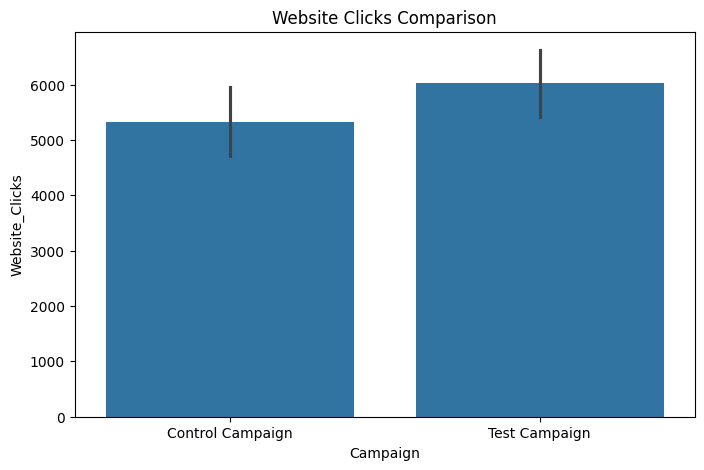

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(x="Campaign", y="Website_Clicks", data=data)
plt.title("Website Clicks Comparison")
plt.show()

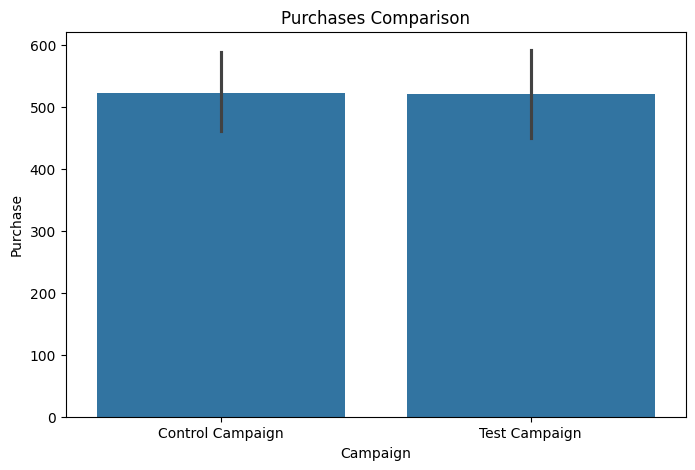

In [37]:
plt.figure(figsize=(8,5))
sns.barplot(x="Campaign", y="Purchase", data=data)
plt.title("Purchases Comparison")
plt.show()

In [39]:
data["Conversion Rate"] = data["Purchase"] / data["Website_Clicks"]

In [40]:
data.groupby("Campaign")["Conversion Rate"].mean()

Campaign
Control Campaign    0.114772
Test Campaign       0.092312
Name: Conversion Rate, dtype: float64

#### Performing a t-test to determine whether the difference in purchases between the campaigns is statistically significant.

* Hypothesis-
**Null Hypothesis (H0):** There is no difference between the campaigns.
**Alternative Hypothesis (H1):** The test campaign performs differently from the control campaign.

In [44]:
from scipy.stats import ttest_ind

control_purchases = control["Purchase"]
test_purchases = test["Purchase"]

t_stat, p_value = ttest_ind(control_purchases, test_purchases)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: nan
P-value: nan


In [45]:
control["Purchase"].dtype
test["Purchase"].dtype

dtype('int64')

In [46]:
control["Purchase"].unique()
test["Purchase"].unique()

array([255, 677, 578, 340, 768, 488, 890, 431, 845, 275, 668, 709, 812,
       398, 487, 238, 257, 512, 730, 245, 276, 473, 269, 651, 284, 771,
       721, 572])

In [50]:
control_purchases = control["Purchase"].dropna()
test_purchases = test["Purchase"].dropna()

t_stat, p_value = ttest_ind(control_purchases, test_purchases)

print("T-statistic:", t_stat)
print("P-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Result: The difference between campaigns is statistically significant.")
    print("The Test Campaign performs differently from the Control Campaign.")
else:
    print("Result: The difference between campaigns is not statistically significant.")
    print("The observed difference may be due to random variation.")

T-statistic: 0.03014479856562245
P-value: 0.9760568756579724
Result: The difference between campaigns is not statistically significant.
The observed difference may be due to random variation.


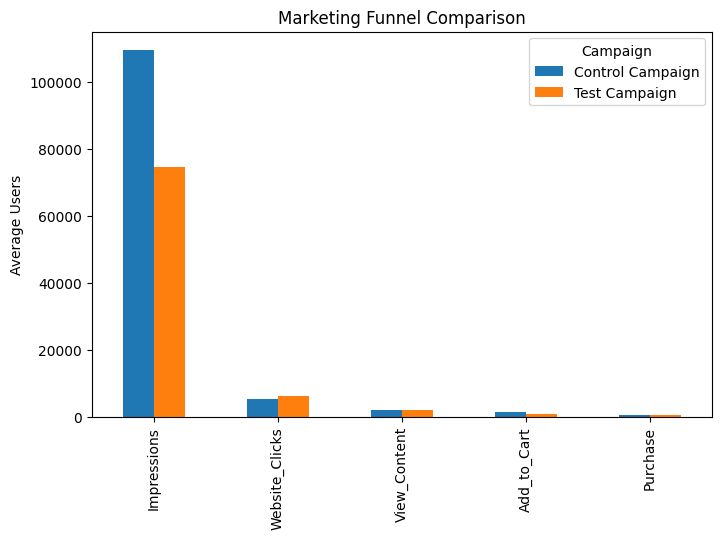

In [49]:
funnel = data.groupby("Campaign")[[
    "Impressions","Website_Clicks","View_Content",
    "Add_to_Cart","Purchase"
]].mean()

funnel.T.plot(kind="bar", figsize=(8,5))
plt.title("Marketing Funnel Comparison")
plt.ylabel("Average Users")
plt.show()

#### From the A/B testing analysis:

* Both campaigns were compared using engagement and purchase metrics.
* Visualization helped analyze user behavior across the marketing funnel.
* A statistical t-test was used to determine whether differences were significant.

This approach helps businesses optimize marketing strategies and improve conversion rates using data-driven decisions.